# Tempo MCMC

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd


data = pd.read_csv('./time_data.csv', sep=";")
data['Tempo MCMC'] = data['Tempo MCMC'].str.replace(',', '.').astype(float)
data['Tempo SAEM'] = data['Tempo SAEM'].str.replace(',', '.').astype(float)
x_to_pred = [4000000]
display(data)

,Visite,Pazienti,Iterazioni,Tempo TOT,Tempo MCMC,Tempo SAEM,Tempo Medio Iterazione,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,5639,1000,1000,43,6.51,36.49,"0,03649",NaN,NaN,NaN
1,11310,2000,1000,46,9.32,36.68,"0,03668",NaN,NaN,NaN
2,28150,5000,1000,"64,3",21.81,42.49,"0,04249",NaN,NaN,NaN
3,56154,10000,1000,"74,26",34.92,39.34,"0,03934",NaN,NaN,NaN
4,140486,25000,1000,"142,21",96.63,45.58,"0,04558",NaN,NaN,NaN
5,281031,50000,1000,"301,3",243.48,57.82,"0,05782",NaN,NaN,NaN
6,421933,75000,1000,"580,97",502.42,78.55,"0,07855",NaN,NaN,NaN
7,562652,100000,1000,"986,49",883.51,102.98,"0,10298",NaN,NaN,NaN
8,844374,150000,1000,"2051,81",1881.84,169.97,"0,16997",NaN,NaN,NaN
9,1125802,200000,1000,"7893,33",7517.94,375.39,"0,37539",NaN,NaN,NaN


In [2]:
def polynomial_regression(x,y,i):
    poly = PolynomialFeatures(degree=i)
    visits_poly = poly.fit_transform(x)
    model = LinearRegression()
    model.fit(visits_poly, y)
    y_pred = model.predict(visits_poly)

    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    print('Regression with a polynomial of degree ' + str(i) + ': ')
    print('MSE: ', mse)
    print("R2: ", r2)

    plt.scatter(x, y, color='blue', label='Dati osservati')
    plt.plot(x, y_pred, color='red', label='Regressione Polinomiale') 
    plt.show()

    model_type = 'Polynomial n° ' + str(i)

    return mse, r2, model, model_type


In [3]:
def log_regression(x,y):
    X_log = np.log(x)
    log_model = LinearRegression()
    log_model.fit(X_log, y)
    y_pred = log_model.predict(X_log)

    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    print('Regression with a log model: ')
    print('MSE: ', mse)
    print("R2: ", r2)

    plt.scatter(x, y, color='blue', label='Dati osservati')
    plt.plot(x, y_pred, color='red', label='Regressione Polinomiale') 
    plt.show()

    model_type = 'Log'

    return mse, r2, log_model, model_type

Regression with a log model: 
MSE:  3278465.5252455585
R2:  0.3257492506749745


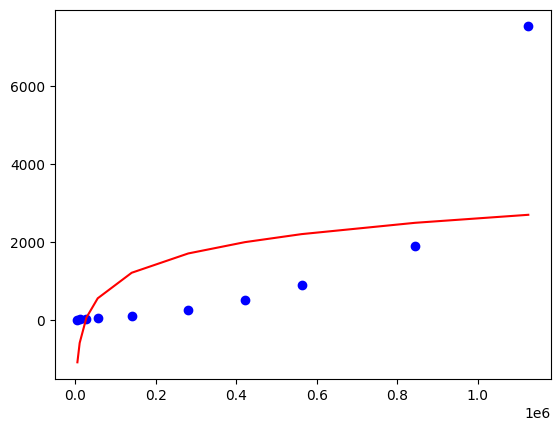

Regression with a polynomial of degree 2: 
MSE:  246173.46592922282
R2:  0.9493718501571601


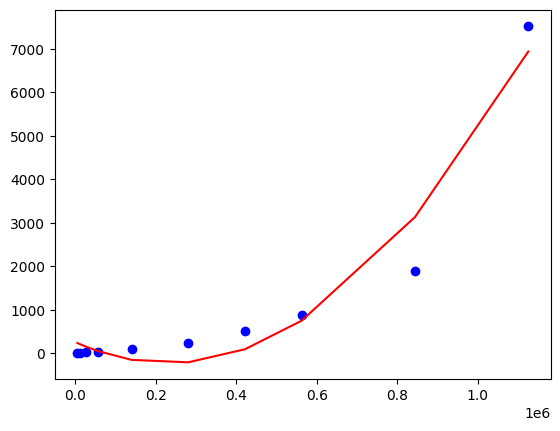

Regression with a polynomial of degree 3: 
MSE:  35151.68167969913
R2:  0.9927706887475058


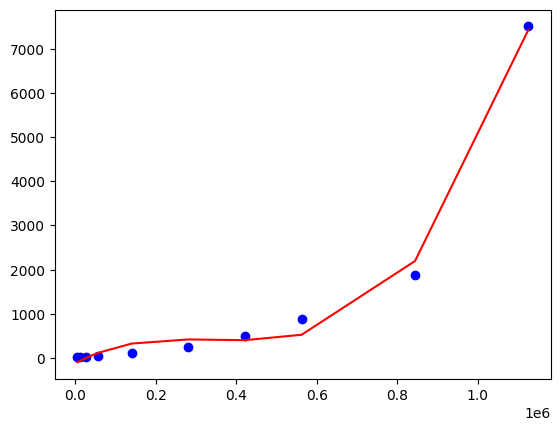

Regression with a polynomial of degree 4: 
MSE:  4710.762919958371
R2:  0.9990311823003121


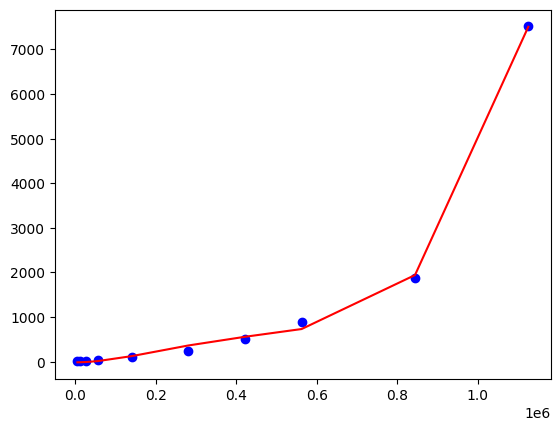

Regression with a polynomial of degree 5: 
MSE:  385.08544332865665
R2:  0.9999208031480828


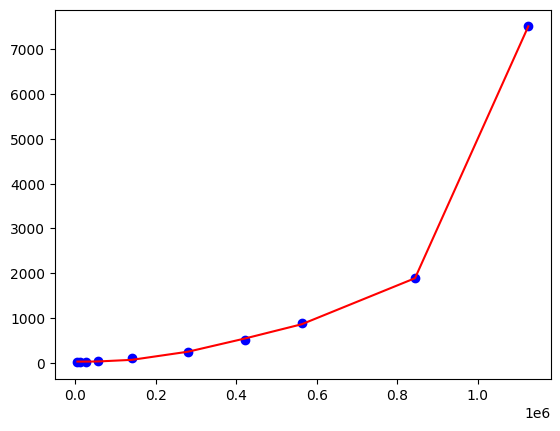

Regression with a polynomial of degree 6: 
MSE:  1246.3767025512507
R2:  0.999743669585919


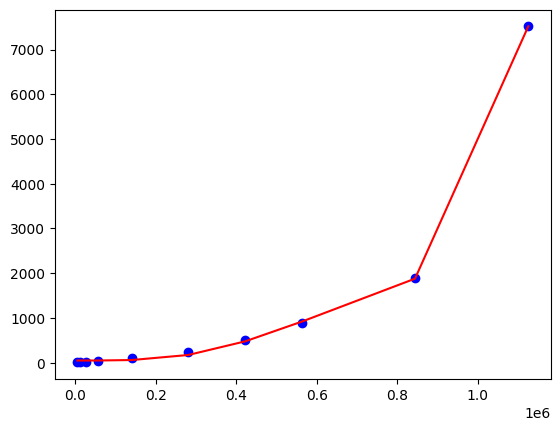

Regression with a polynomial of degree 7: 
MSE:  3551.779064867226
R2:  0.9992695394606157


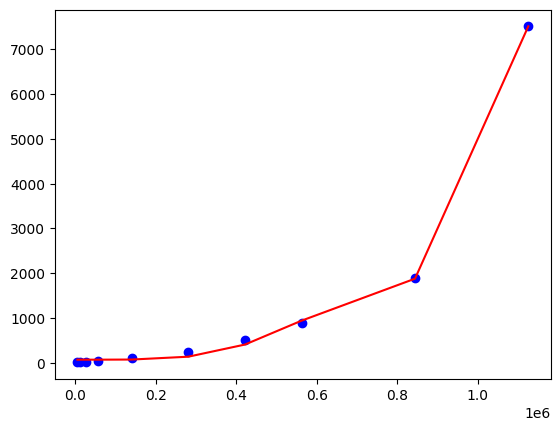

Regression with a polynomial of degree 8: 
MSE:  6246.399798491186
R2:  0.998715362503499


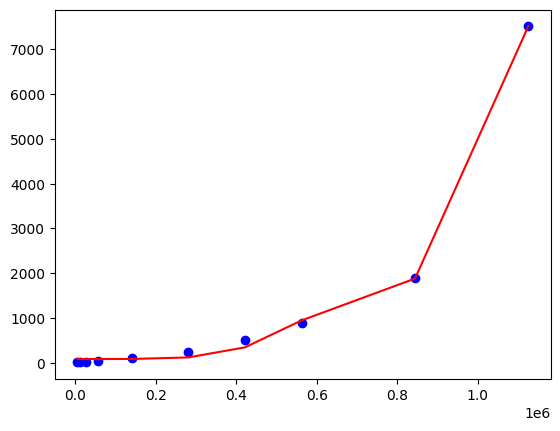

Regression with a polynomial of degree 9: 
MSE:  8877.643141495046
R2:  0.9981742197701027


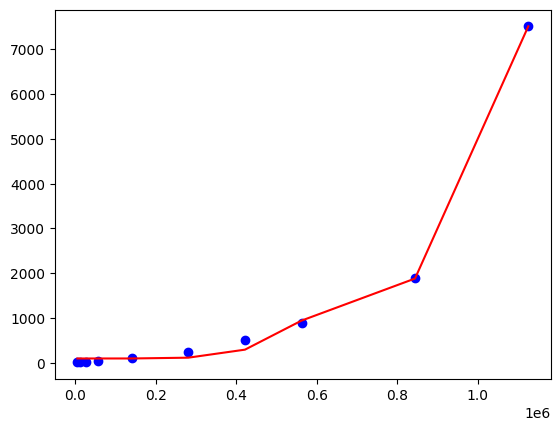

Best fit Model: Polynomial n° 5
MSE: 385.08544332865665
R2: 0.9999208031480828


In [4]:
x = np.asanyarray(data['Visite']).reshape(-1, 1)
#y = np.asanyarray((data['Tempo MCMC'] - data['Tempo MCMC'].min()) / (data['Tempo MCMC'].max() - data['Tempo MCMC'].min()))
y = np.asanyarray(data['Tempo MCMC'])


best_mse, best_r2, best_model, best_model_type = log_regression(x,y)

for i in range(2,10):
    mse, r2, model, model_type = polynomial_regression(x,y,i)
    if mse < best_mse:
        best_mse = mse
        best_r2 = r2
        best_model = model
        best_model_type = model_type


print('Best fit Model: ' + best_model_type)
print('MSE: ' + str(best_mse))
print('R2: ' + str(best_r2))

In [5]:
degree = 5
new_x = np.array(x_to_pred).reshape(-1,1)

poly = PolynomialFeatures(degree=degree)
visits_poly = poly.fit_transform(new_x)
y_pred_mcmc = best_model.predict(visits_poly)

# Tempo SAEM

Regression with a log model: 
MSE:  5773.072603165508
R2:  0.42814517239897565


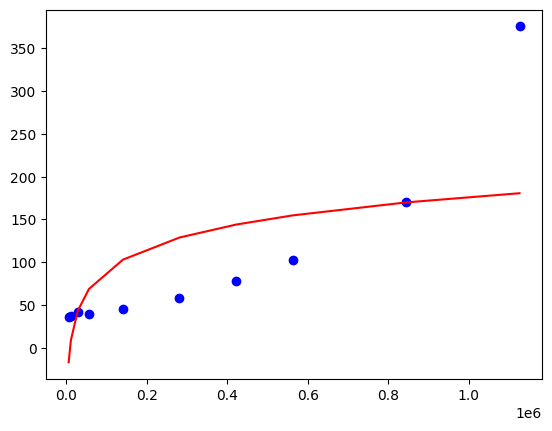

Regression with a polynomial of degree 2: 
MSE:  184.23381502971955
R2:  0.9817506198563429


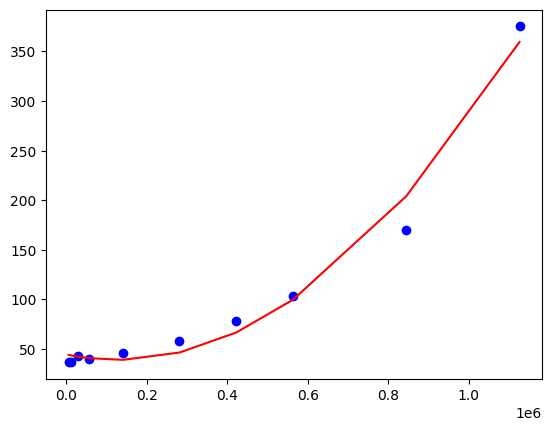

Regression with a polynomial of degree 3: 
MSE:  28.423511480760045
R2:  0.9971844937046638


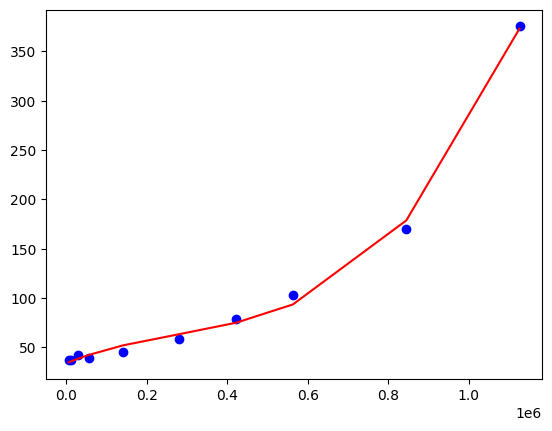

Regression with a polynomial of degree 4: 
MSE:  4.3754254294882395
R2:  0.9995665898687487


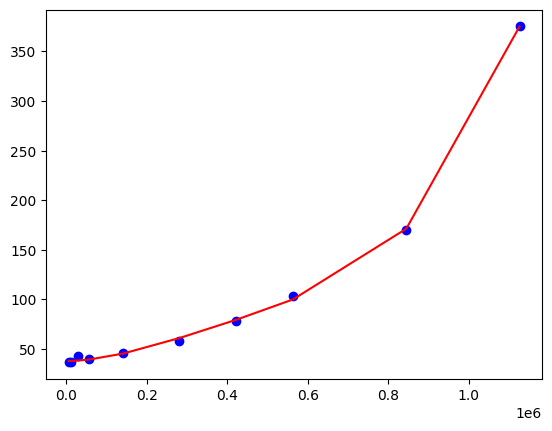

Regression with a polynomial of degree 5: 
MSE:  5.125884636024333
R2:  0.9994922527263508


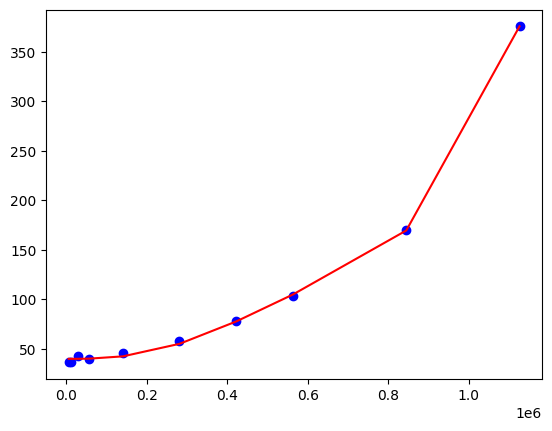

Regression with a polynomial of degree 6: 
MSE:  16.99535517270421
R2:  0.998316515905763


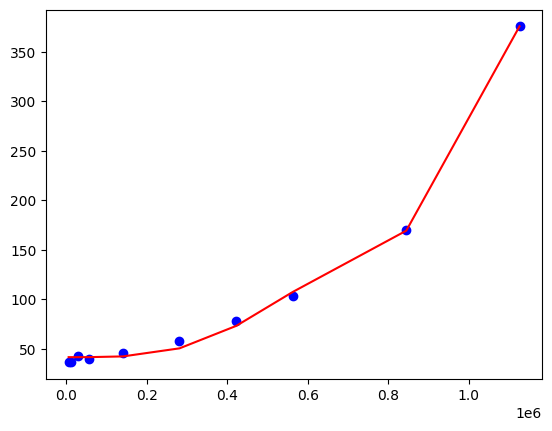

Regression with a polynomial of degree 7: 
MSE:  34.00124520901165
R2:  0.9966319882749165


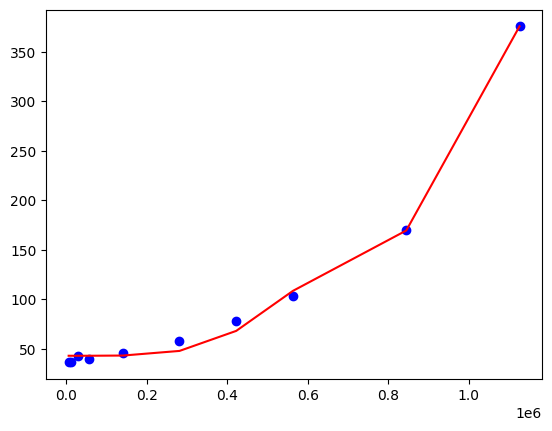

Regression with a polynomial of degree 8: 
MSE:  52.2527349669556
R2:  0.9948240770902784


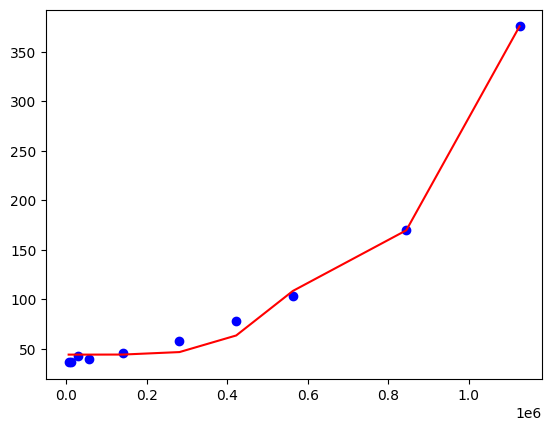

Regression with a polynomial of degree 9: 
MSE:  69.44080888217718
R2:  0.9931215031368185


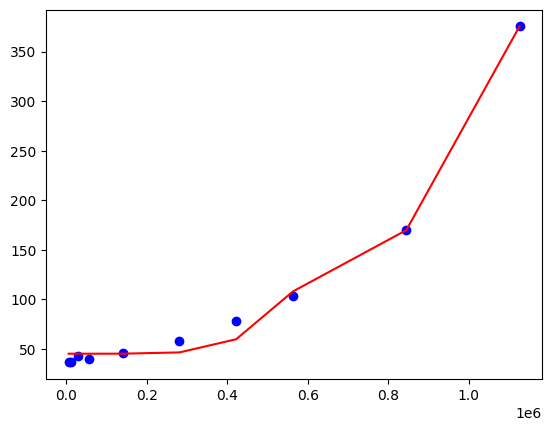

Best fit Model: Polynomial n° 4
MSE: 4.3754254294882395
R2: 0.9995665898687487


In [6]:
y = np.asanyarray(data['Tempo SAEM'])

best_mse, best_r2, best_model, best_model_type = log_regression(x,y)

for i in range(2,10):
    mse, r2, model, model_type = polynomial_regression(x,y,i)
    if mse < best_mse:
        best_mse = mse
        best_r2 = r2
        best_model = model
        best_model_type = model_type


print('Best fit Model: ' + best_model_type)
print('MSE: ' + str(best_mse))
print('R2: ' + str(best_r2))

In [7]:
degree = 4
new_x = np.array(x_to_pred).reshape(-1,1)

poly = PolynomialFeatures(degree=degree)
visits_poly = poly.fit_transform(new_x)
y_pred_saem = best_model.predict(visits_poly)

In [8]:
num_int = 3000
time_tot = y_pred_mcmc[0] + y_pred_saem[0]
days = time_tot // 86400
hours = (time_tot % 86400) // 3600
minutes = ((time_tot % 86400) % 3600) // 60
seconds = ((time_tot % 86400) % 3600) % 60


print(f'Totale in secondi: {time_tot}')
print(f'Tempo per {num_int} iterazioni: {days} d {hours} h {minutes} m {seconds} s')

Totale in secondi: 15543274.204757884
Tempo per 3000 iterazioni: 179.0 d 21.0 h 34.0 m 34.20475788414478 s
